<a href="https://colab.research.google.com/github/Nickhilsekar/spider_ml/blob/main/spider_research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FashionModel(nn.Module):
    def __init__(self):
        super(FashionModel, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(784, 16)

        # Parallel Branch 1
        self.fc_p1_1 = nn.Linear(16, 8)
        self.fc_p1_2 = nn.Linear(8, 8)

        # Parallel Branch 2
        self.fc_p2_1 = nn.Linear(16, 12)
        self.fc_p2_2 = nn.Linear(12, 8)

        self.output = nn.Linear(16, 10) # 10 classes for Fashion-MNIST

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))

        # Skip Connection Branch
        identity = F.relu(self.fc_p1_1(x))
        p1 = F.relu(self.fc_p1_2(identity))
        p1 = p1 + identity # Skip connection add

        # Second Branch
        p2 = F.relu(self.fc_p2_1(x))
        p2 = F.relu(self.fc_p2_2(p2))

        # Concatenate and Output
        combined = torch.cat((p1, p2), dim=1)
        return self.output(combined)

## Data Preparation: Fashion-MNIST

First, we'll load the Fashion-MNIST dataset, which is a common benchmark for image classification. We'll also define data loaders for training and testing.

In [ ]:
import torchvision
import torchvision.transforms as transforms

# Define a transform to normalize the data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load the Fashion-MNIST training and test datasets
train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Create data loaders
batch_size = 64
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 304kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.65MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.0MB/s]

Number of training samples: 60000
Number of test samples: 10000


## Training and Evaluation Functions

Now, let's define standard training and evaluation functions that we'll use for both normal training and label smoothing experiments.

In [ ]:
def train(model, device, train_loader, optimizer, epoch, criterion):
    model.train()
    running_loss = 0.0
    correct = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * data.size(0)
        pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
        correct += pred.eq(target.view_as(pred)).sum().item()

        if batch_idx % 100 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} ({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}')

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct / len(train_loader.dataset)
    return epoch_loss, epoch_acc

def test(model, device, test_loader, criterion):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item() * data.size(0)  # sum up batch loss
            pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)
    test_acc = correct / len(test_loader.dataset)

    print(f'\nTest set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} ({100. * test_acc:.0f}%)\n')
    return test_loss, test_acc

## Normal Training

Now, let's train our `FashionModel` without any label smoothing to establish a baseline performance.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model_normal = FashionModel().to(device)
optimizer_normal = torch.optim.Adam(model_normal.parameters(), lr=0.001)
criterion_normal = nn.CrossEntropyLoss()

epochs = 5
normal_train_losses = []
normal_train_accuracies = []
normal_test_losses = []
normal_test_accuracies = []

for epoch in range(1, epochs + 1):
    train_loss, train_acc = train(model_normal, device, train_loader, optimizer_normal, epoch, criterion_normal)
    test_loss, test_acc = test(model_normal, device, test_loader, criterion_normal)
    normal_train_losses.append(train_loss)
    normal_train_accuracies.append(train_acc)
    normal_test_losses.append(test_loss)
    normal_test_accuracies.append(test_acc)

print("Normal training complete.")

Using device: cpu
Train Epoch: 1 [0/60000 (0%)]	Loss: 2.279130
Train Epoch: 1 [6400/60000 (11%)]	Loss: 1.165755
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.711166
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.659488
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.712288
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.428860
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.622502
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.797957
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.561583
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.374274

Test set: Average loss: 0.5159, Accuracy: 8176/10000 (82%)

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.326413
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.312517
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.531552
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.486396
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.508097
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.499783
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.466262
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.382105
Train Epoch: 2 [51200/60000 (85%)

## Label Smoothing Implementation

Now, let's implement the `LabelSmoothingLoss` to compare its effect on the model's performance.

In [ ]:
class LabelSmoothingLoss(nn.Module):
    def __init__(self, classes, smoothing=0.1, dim=-1):
        super(LabelSmoothingLoss, self).__init__()
        self.confidence = 1.0 - smoothing
        self.smoothing = smoothing
        self.cls = classes
        self.dim = dim

    def forward(self, pred, target):
        pred = pred.log_softmax(dim=self.dim)
        with torch.no_grad():
            true_dist = torch.zeros_like(pred)
            true_dist.fill_(self.smoothing / (self.cls - 1))
            true_dist.scatter_(1, target.data.unsqueeze(1), self.confidence)
        return torch.mean(torch.sum(-true_dist * pred, dim=self.dim))

## Training with Label Smoothing

Let's train a new instance of our `FashionModel` using the `LabelSmoothingLoss` with a smoothing value of `0.2`.

In [ ]:
model_ls = FashionModel().to(device)
optimizer_ls = torch.optim.Adam(model_ls.parameters(), lr=0.001)
criterion_ls = LabelSmoothingLoss(classes=10, smoothing=0.2)

ls_train_losses = []
ls_train_accuracies = []
ls_test_losses = []
ls_test_accuracies = []

print("Training with Label Smoothing...")
for epoch in range(1, epochs + 1):
    train_loss, train_acc = train(model_ls, device, train_loader, optimizer_ls, epoch, criterion_ls)
    test_loss, test_acc = test(model_ls, device, test_loader, criterion_ls)
    ls_train_losses.append(train_loss)
    ls_train_accuracies.append(train_acc)
    ls_test_losses.append(test_loss)
    ls_test_accuracies.append(test_acc)

print("Label Smoothing training complete.")

Training with Label Smoothing...
Train Epoch: 1 [0/60000 (0%)]	Loss: 2.296008
Train Epoch: 1 [6400/60000 (11%)]	Loss: 1.451625
Train Epoch: 1 [12800/60000 (21%)]	Loss: 1.424085
Train Epoch: 1 [19200/60000 (32%)]	Loss: 1.327482
Train Epoch: 1 [25600/60000 (43%)]	Loss: 1.351963
Train Epoch: 1 [32000/60000 (53%)]	Loss: 1.275796
Train Epoch: 1 [38400/60000 (64%)]	Loss: 1.252693
Train Epoch: 1 [44800/60000 (75%)]	Loss: 1.211097
Train Epoch: 1 [51200/60000 (85%)]	Loss: 1.251788
Train Epoch: 1 [57600/60000 (96%)]	Loss: 1.245277

Test set: Average loss: 1.2640, Accuracy: 8202/10000 (82%)

Train Epoch: 2 [0/60000 (0%)]	Loss: 1.190774
Train Epoch: 2 [6400/60000 (11%)]	Loss: 1.315060
Train Epoch: 2 [12800/60000 (21%)]	Loss: 1.182979
Train Epoch: 2 [19200/60000 (32%)]	Loss: 1.217725
Train Epoch: 2 [25600/60000 (43%)]	Loss: 1.222849
Train Epoch: 2 [32000/60000 (53%)]	Loss: 1.261141
Train Epoch: 2 [38400/60000 (64%)]	Loss: 1.169950
Train Epoch: 2 [44800/60000 (75%)]	Loss: 1.207894
Train Epoch: 2 [51

## Training with Label Smoothing (`smoothing=0.1`)

Let's re-run the training with the original `smoothing=0.1` value and store its results in separate variables for comparison.

In [ ]:
model_ls_01 = FashionModel().to(device)
optimizer_ls_01 = torch.optim.Adam(model_ls_01.parameters(), lr=0.001)
criterion_ls_01 = LabelSmoothingLoss(classes=10, smoothing=0.1)

ls_01_train_losses = []
ls_01_train_accuracies = []
ls_01_test_losses = []
ls_01_test_accuracies = []

print("Training with Label Smoothing (smoothing=0.1)...")
for epoch in range(1, epochs + 1):
    train_loss, train_acc = train(model_ls_01, device, train_loader, optimizer_ls_01, epoch, criterion_ls_01)
    test_loss, test_acc = test(model_ls_01, device, test_loader, criterion_ls_01)
    ls_01_train_losses.append(train_loss)
    ls_01_train_accuracies.append(train_acc)
    ls_01_test_losses.append(test_loss)
    ls_01_test_accuracies.append(test_acc)

print("Label Smoothing (smoothing=0.1) training complete.")

Training with Label Smoothing (smoothing=0.1)...
Train Epoch: 1 [0/60000 (0%)]	Loss: 2.303208
Train Epoch: 1 [6400/60000 (11%)]	Loss: 1.235371
Train Epoch: 1 [12800/60000 (21%)]	Loss: 1.069093
Train Epoch: 1 [19200/60000 (32%)]	Loss: 1.006135
Train Epoch: 1 [25600/60000 (43%)]	Loss: 1.138757
Train Epoch: 1 [32000/60000 (53%)]	Loss: 1.023955
Train Epoch: 1 [38400/60000 (64%)]	Loss: 1.010739
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.993383
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.837263
Train Epoch: 1 [57600/60000 (96%)]	Loss: 1.047530

Test set: Average loss: 0.9508, Accuracy: 8251/10000 (83%)

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.934798
Train Epoch: 2 [6400/60000 (11%)]	Loss: 1.038198
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.892595
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.903504
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.788114
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.983602
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.920204
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.857952
Tr

## Training with Label Smoothing (`smoothing=0.2`)

Now, let's capture the results for `smoothing=0.2` again (which is currently in `ls_*` variables), but explicitly for this comparison.

In [ ]:
model_ls_02 = FashionModel().to(device)
optimizer_ls_02 = torch.optim.Adam(model_ls_02.parameters(), lr=0.001)
criterion_ls_02 = LabelSmoothingLoss(classes=10, smoothing=0.2)

ls_02_train_losses = []
ls_02_train_accuracies = []
ls_02_test_losses = []
ls_02_test_accuracies = []

print("Training with Label Smoothing (smoothing=0.2)...")
for epoch in range(1, epochs + 1):
    train_loss, train_acc = train(model_ls_02, device, train_loader, optimizer_ls_02, epoch, criterion_ls_02)
    test_loss, test_acc = test(model_ls_02, device, test_loader, criterion_ls_02)
    ls_02_train_losses.append(train_loss)
    ls_02_train_accuracies.append(train_acc)
    ls_02_test_losses.append(test_loss)
    ls_02_test_accuracies.append(test_acc)

print("Label Smoothing (smoothing=0.2) training complete.")

Training with Label Smoothing (smoothing=0.2)...
Train Epoch: 1 [0/60000 (0%)]	Loss: 2.338490
Train Epoch: 1 [6400/60000 (11%)]	Loss: 1.468057
Train Epoch: 1 [12800/60000 (21%)]	Loss: 1.370577
Train Epoch: 1 [19200/60000 (32%)]	Loss: 1.304800
Train Epoch: 1 [25600/60000 (43%)]	Loss: 1.225574
Train Epoch: 1 [32000/60000 (53%)]	Loss: 1.323956
Train Epoch: 1 [38400/60000 (64%)]	Loss: 1.232058
Train Epoch: 1 [44800/60000 (75%)]	Loss: 1.274999
Train Epoch: 1 [51200/60000 (85%)]	Loss: 1.278812
Train Epoch: 1 [57600/60000 (96%)]	Loss: 1.175751

Test set: Average loss: 1.2735, Accuracy: 8076/10000 (81%)

Train Epoch: 2 [0/60000 (0%)]	Loss: 1.267626
Train Epoch: 2 [6400/60000 (11%)]	Loss: 1.262120
Train Epoch: 2 [12800/60000 (21%)]	Loss: 1.313738
Train Epoch: 2 [19200/60000 (32%)]	Loss: 1.204666
Train Epoch: 2 [25600/60000 (43%)]	Loss: 1.252647
Train Epoch: 2 [32000/60000 (53%)]	Loss: 1.228554
Train Epoch: 2 [38400/60000 (64%)]	Loss: 1.218991
Train Epoch: 2 [44800/60000 (75%)]	Loss: 1.228764
Tr

## Comparative Performance Analysis

Let's visualize the training and test loss and accuracy for normal training, label smoothing with `0.1`, and label smoothing with `0.2`.

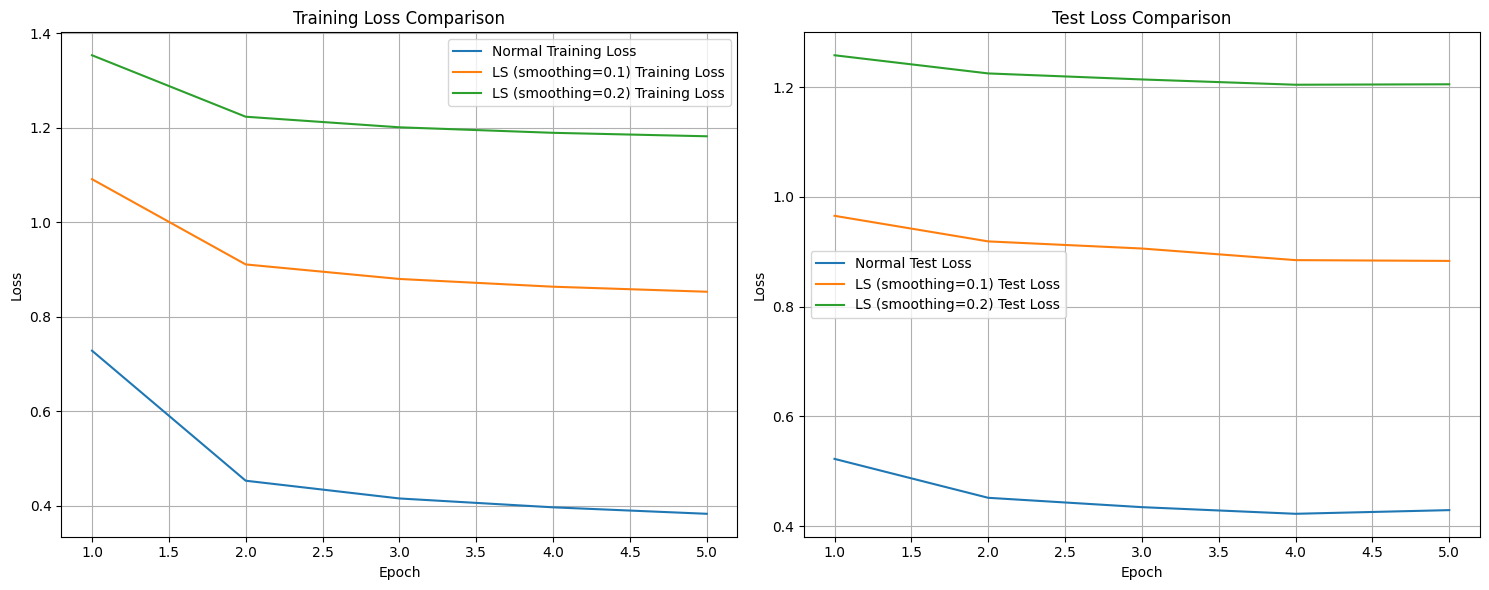

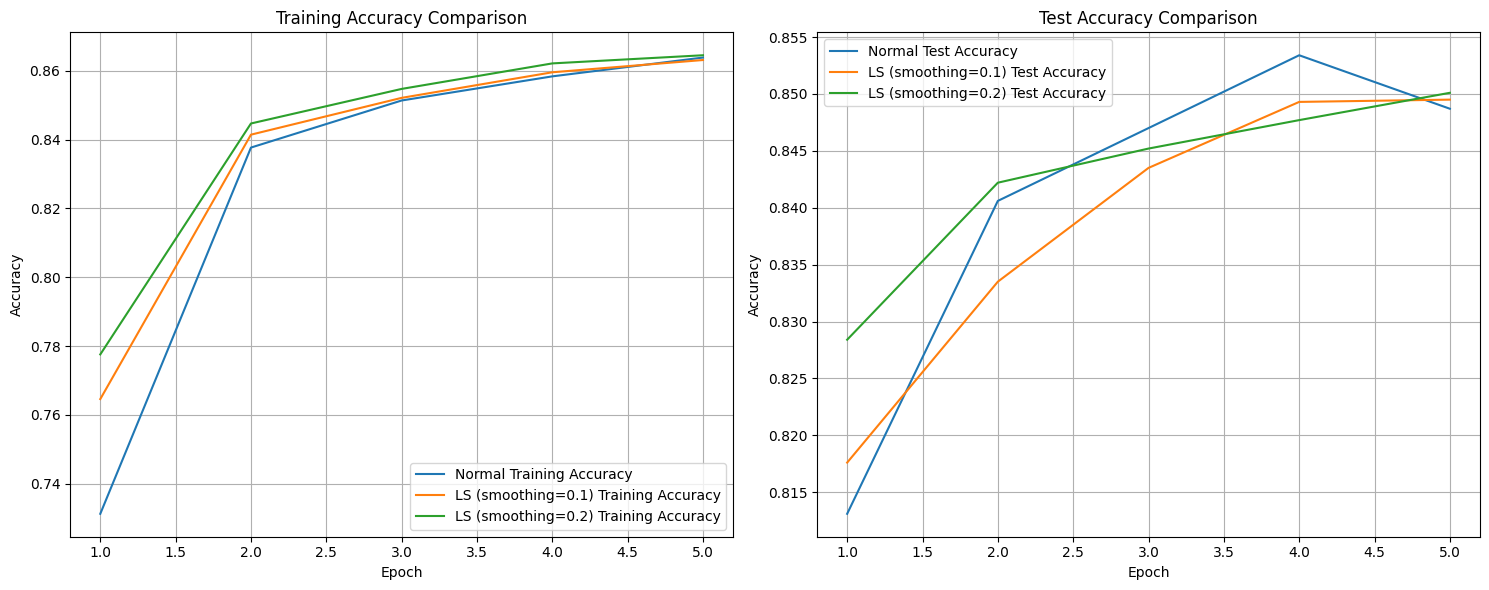

Final Normal Test Accuracy: 84.87%
Final Label Smoothing (smoothing=0.1) Test Accuracy: 84.95%
Final Label Smoothing (smoothing=0.2) Test Accuracy: 85.01%


In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, epochs + 1)

plt.figure(figsize=(15, 6))

# Plot Training Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, normal_train_losses, label='Normal Training Loss')
plt.plot(epochs_range, ls_01_train_losses, label='LS (smoothing=0.1) Training Loss')
plt.plot(epochs_range, ls_02_train_losses, label='LS (smoothing=0.2) Training Loss')
plt.title('Training Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Test Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, normal_test_losses, label='Normal Test Loss')
plt.plot(epochs_range, ls_01_test_losses, label='LS (smoothing=0.1) Test Loss')
plt.plot(epochs_range, ls_02_test_losses, label='LS (smoothing=0.2) Test Loss')
plt.title('Test Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 6))

# Plot Training Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, normal_train_accuracies, label='Normal Training Accuracy')
plt.plot(epochs_range, ls_01_train_accuracies, label='LS (smoothing=0.1) Training Accuracy')
plt.plot(epochs_range, ls_02_train_accuracies, label='LS (smoothing=0.2) Training Accuracy')
plt.title('Training Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Test Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, normal_test_accuracies, label='Normal Test Accuracy')
plt.plot(epochs_range, ls_01_test_accuracies, label='LS (smoothing=0.1) Test Accuracy')
plt.plot(epochs_range, ls_02_test_accuracies, label='LS (smoothing=0.2) Test Accuracy')
plt.title('Test Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Final Normal Test Accuracy: {normal_test_accuracies[-1]*100:.2f}%")
print(f"Final Label Smoothing (smoothing=0.1) Test Accuracy: {ls_01_test_accuracies[-1]*100:.2f}%")
print(f"Final Label Smoothing (smoothing=0.2) Test Accuracy: {ls_02_test_accuracies[-1]*100:.2f}%")

## Prediction Confidence Analysis

To analyze the prediction confidence, we will extract the model outputs (logits) for the test set for each of our trained models and convert them into probabilities. Then, we can visualize the distribution of these probabilities.

In [ ]:
def get_predictions(model, device, data_loader):
    model.eval()
    all_outputs = []
    all_targets = []
    with torch.no_grad():
        for data, target in data_loader:
            data = data.to(device)
            output = model(data)
            all_outputs.append(output.cpu())
            all_targets.append(target.cpu())
    return torch.cat(all_outputs), torch.cat(all_targets)

# Get predictions for all models
outputs_normal, targets_normal = get_predictions(model_normal, device, test_loader)
outputs_ls_01, targets_ls_01 = get_predictions(model_ls_01, device, test_loader)
outputs_ls_02, targets_ls_02 = get_predictions(model_ls_02, device, test_loader)

# Convert logits to probabilities
probs_normal = F.softmax(outputs_normal, dim=1)
probs_ls_01 = F.softmax(outputs_ls_01, dim=1)
probs_ls_02 = F.softmax(outputs_ls_02, dim=1)

# Get predicted classes and their confidence (max probability)
max_probs_normal, predicted_normal = torch.max(probs_normal, dim=1)
max_probs_ls_01, predicted_ls_01 = torch.max(probs_ls_01, dim=1)
max_probs_ls_02, predicted_ls_02 = torch.max(probs_ls_02, dim=1)

# Identify correct and incorrect predictions
correct_normal = (predicted_normal == targets_normal)
correct_ls_01 = (predicted_ls_01 == targets_ls_01)
correct_ls_02 = (predicted_ls_02 == targets_ls_02)

# Get confidence for correct and incorrect predictions
conf_correct_normal = max_probs_normal[correct_normal]
conf_incorrect_normal = max_probs_normal[~correct_normal]

conf_correct_ls_01 = max_probs_ls_01[correct_ls_01]
conf_incorrect_ls_01 = max_probs_ls_01[~correct_ls_01]

conf_correct_ls_02 = max_probs_ls_02[correct_ls_02]
conf_incorrect_ls_02 = max_probs_ls_02[~correct_ls_02]

print("Prediction confidence data prepared.")

Prediction confidence data prepared.


### Confidence Distribution Histograms

Let's visualize the distribution of maximum prediction probabilities (confidence) for correctly and incorrectly classified samples for each model. A well-calibrated model should ideally have high confidence for correct predictions and low confidence for incorrect ones.

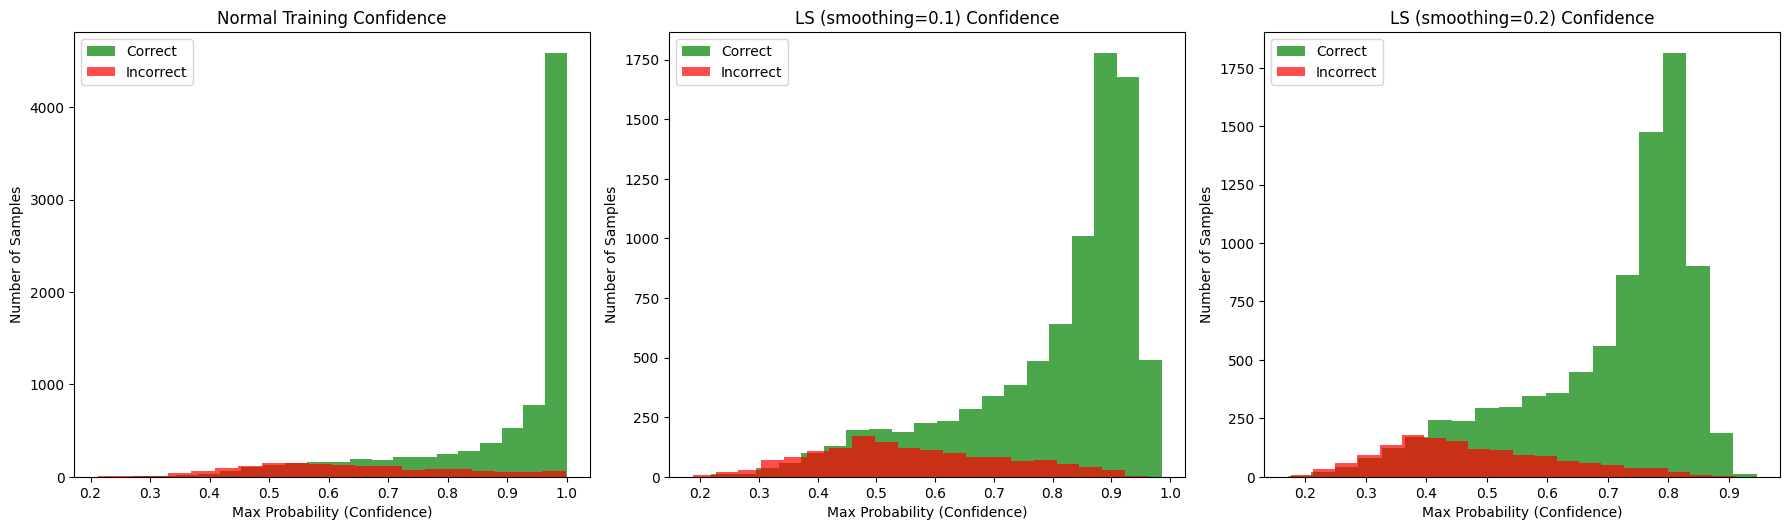


Average Confidence for Correct Predictions:
  Normal: 0.8940
  LS (smoothing=0.1): 0.7995
  LS (smoothing=0.2): 0.7027

Average Confidence for Incorrect Predictions:
  Normal: 0.6310
  LS (smoothing=0.1): 0.5581
  LS (smoothing=0.2): 0.4775


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 10))

# Normal Training
plt.subplot(2, 3, 1)
plt.hist(conf_correct_normal.numpy(), bins=20, alpha=0.7, label='Correct', color='green')
plt.hist(conf_incorrect_normal.numpy(), bins=20, alpha=0.7, label='Incorrect', color='red')
plt.title('Normal Training Confidence')
plt.xlabel('Max Probability (Confidence)')
plt.ylabel('Number of Samples')
plt.legend()

# Label Smoothing (smoothing=0.1)
plt.subplot(2, 3, 2)
plt.hist(conf_correct_ls_01.numpy(), bins=20, alpha=0.7, label='Correct', color='green')
plt.hist(conf_incorrect_ls_01.numpy(), bins=20, alpha=0.7, label='Incorrect', color='red')
plt.title('LS (smoothing=0.1) Confidence')
plt.xlabel('Max Probability (Confidence)')
plt.ylabel('Number of Samples')
plt.legend()

# Label Smoothing (smoothing=0.2)
plt.subplot(2, 3, 3)
plt.hist(conf_correct_ls_02.numpy(), bins=20, alpha=0.7, label='Correct', color='green')
plt.hist(conf_incorrect_ls_02.numpy(), bins=20, alpha=0.7, label='Incorrect', color='red')
plt.title('LS (smoothing=0.2) Confidence')
plt.xlabel('Max Probability (Confidence)')
plt.ylabel('Number of Samples')
plt.legend()

plt.tight_layout()
plt.show()

# Average Confidence
print("\nAverage Confidence for Correct Predictions:")
print(f"  Normal: {conf_correct_normal.mean():.4f}")
print(f"  LS (smoothing=0.1): {conf_correct_ls_01.mean():.4f}")
print(f"  LS (smoothing=0.2): {conf_correct_ls_02.mean():.4f}")

print("\nAverage Confidence for Incorrect Predictions:")
print(f"  Normal: {conf_incorrect_normal.mean():.4f}")
print(f"  LS (smoothing=0.1): {conf_incorrect_ls_01.mean():.4f}")
print(f"  LS (smoothing=0.2): {conf_incorrect_ls_02.mean():.4f}")

## Performance Comparison

Let's visualize the training and test loss and accuracy for both normal training and training with Label Smoothing to compare their performance.

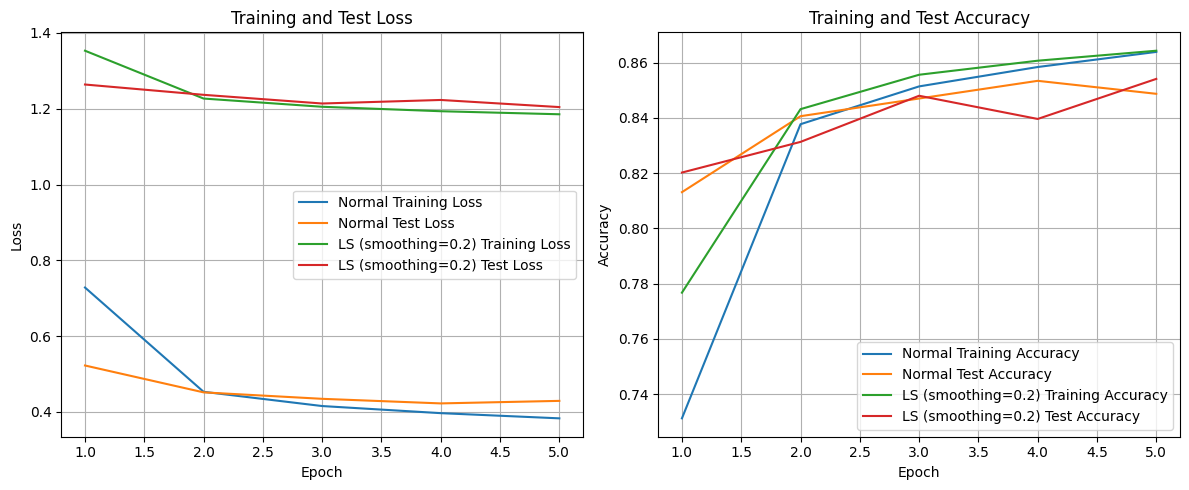

Final Normal Test Accuracy: 84.87%
Final Label Smoothing (smoothing=0.2) Test Accuracy: 85.41%


In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, epochs + 1)

plt.figure(figsize=(12, 5))

# Plot Training & Validation Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, normal_train_losses, label='Normal Training Loss')
plt.plot(epochs_range, normal_test_losses, label='Normal Test Loss')
plt.plot(epochs_range, ls_train_losses, label='LS (smoothing=0.2) Training Loss')
plt.plot(epochs_range, ls_test_losses, label='LS (smoothing=0.2) Test Loss')
plt.title('Training and Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Training & Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, normal_train_accuracies, label='Normal Training Accuracy')
plt.plot(epochs_range, normal_test_accuracies, label='Normal Test Accuracy')
plt.plot(epochs_range, ls_train_accuracies, label='LS (smoothing=0.2) Training Accuracy')
plt.plot(epochs_range, ls_test_accuracies, label='LS (smoothing=0.2) Test Accuracy')
plt.title('Training and Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Final Normal Test Accuracy: {normal_test_accuracies[-1]*100:.2f}%")
print(f"Final Label Smoothing (smoothing=0.2) Test Accuracy: {ls_test_accuracies[-1]*100:.2f}%")

## Performance Comparison

Let's visualize the training and test loss and accuracy for both normal training and training with Label Smoothing to compare their performance.

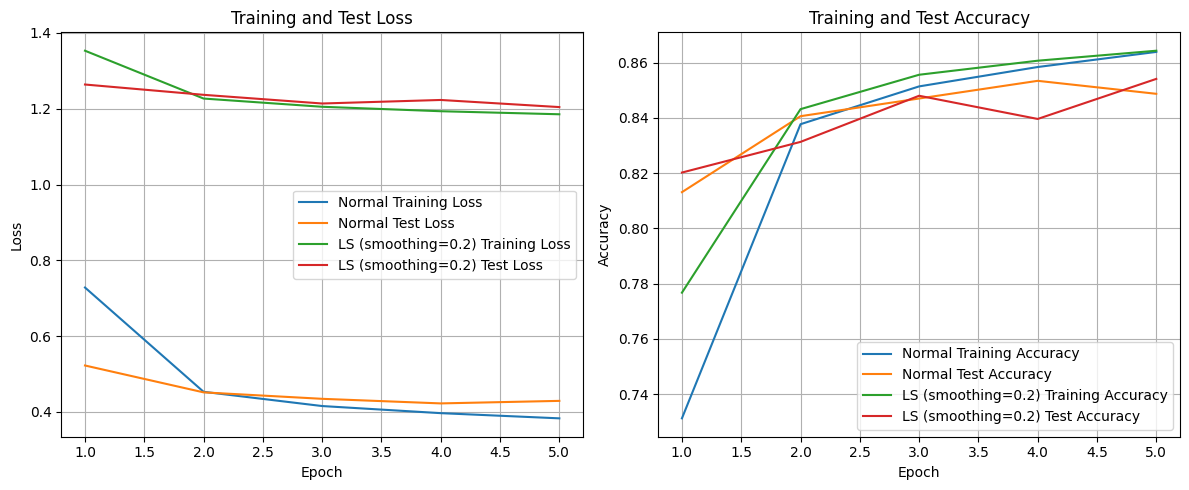

Final Normal Test Accuracy: 84.87%
Final Label Smoothing (smoothing=0.2) Test Accuracy: 85.41%


In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, epochs + 1)

plt.figure(figsize=(12, 5))

# Plot Training & Validation Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, normal_train_losses, label='Normal Training Loss')
plt.plot(epochs_range, normal_test_losses, label='Normal Test Loss')
plt.plot(epochs_range, ls_train_losses, label='LS (smoothing=0.2) Training Loss')
plt.plot(epochs_range, ls_test_losses, label='LS (smoothing=0.2) Test Loss')
plt.title('Training and Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Training & Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, normal_train_accuracies, label='Normal Training Accuracy')
plt.plot(epochs_range, normal_test_accuracies, label='Normal Test Accuracy')
plt.plot(epochs_range, ls_train_accuracies, label='LS (smoothing=0.2) Training Accuracy')
plt.plot(epochs_range, ls_test_accuracies, label='LS (smoothing=0.2) Test Accuracy')
plt.title('Training and Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Final Normal Test Accuracy: {normal_test_accuracies[-1]*100:.2f}%")
print(f"Final Label Smoothing (smoothing=0.2) Test Accuracy: {ls_test_accuracies[-1]*100:.2f}%")